# YOLO 目标检测实验

本 Notebook 使用 [Ultralytics YOLOv8](https://github.com/ultralytics/ultralytics) 完成目标检测测试。

**环境说明：** 所有依赖包安装于 `./venv/`，请在 Jupyter 中选择 Kernel: **Python (yolo-exp)**

## 1. 环境检查

In [2]:
import sys
import torch

print(f"Python 版本: {sys.version}")
print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("使用 CPU 推理")

Python 版本: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
PyTorch 版本: 2.11.0+cpu
CUDA 可用: False
使用 CPU 推理


## 2. 加载 YOLO 模型

首次运行会自动下载预训练权重 `yolov8n.pt`（约 6MB）到本地。

In [3]:
from ultralytics import YOLO

# 加载 YOLOv8n（最轻量版本，适合快速测试）
# 可选: yolov8s.pt / yolov8m.pt / yolov8l.pt / yolov8x.pt（精度依次提升）
model = YOLO("yolov8n.pt")
print(f"模型加载成功: {type(model)}")
print(f"模型任务类型: {model.task}")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\86177\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
模型加载成功: <class 'ultralytics.models.yolo.model.YOLO'>
模型任务类型: detect


## 3. 对内置样例图片推理（快速验证）

In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

# 使用 ultralytics 内置的测试图片
results = model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    save=True,           # 保存结果图片
    project="./runs",    # 保存到本地 ./runs 目录
    name="test_builtin",
    exist_ok=True,
    conf=0.25            # 置信度阈值
)

# 打印检测结果
result = results[0]
print(f"\n检测到 {len(result.boxes)} 个目标:")
for box in result.boxes:
    cls_id = int(box.cls[0])
    cls_name = model.names[cls_id]
    conf = float(box.conf[0])
    print(f"  - {cls_name}: {conf:.2f}")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 E:\workplace\ipynbProj\exp_1YoloPic\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 61.1ms
Speed: 7.0ms preprocess, 61.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to E:\workplace\ipynbProj\exp_1YoloPic\runs\detect\runs\test_builtin

检测到 6 个目标:
  - bus: 0.87
  - person: 0.87
  - person: 0.85
  - person: 0.83
  - person: 0.26
  - stop sign: 0.26


## 4. 可视化检测结果

C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86177\AppData\Local\Temp\ipykernel_31880\3970640028.py:11: UserWarning: Glyph 20010 (\

FileNotFoundError: [Errno 2] No such file or directory: './runs/test_builtin/result_display.png'

E:\workplace\ipynbProj\exp_1YoloPic\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26816 (\N{CJK UNIFIED IDEOGRAPH-68C0}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
E:\workplace\ipynbProj\exp_1YoloPic\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
E:\workplace\ipynbProj\exp_1YoloPic\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
E:\workplace\ipynbProj\exp_1YoloPic\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
E:\workplace\ipynbProj\exp_1YoloPic\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  func(*a

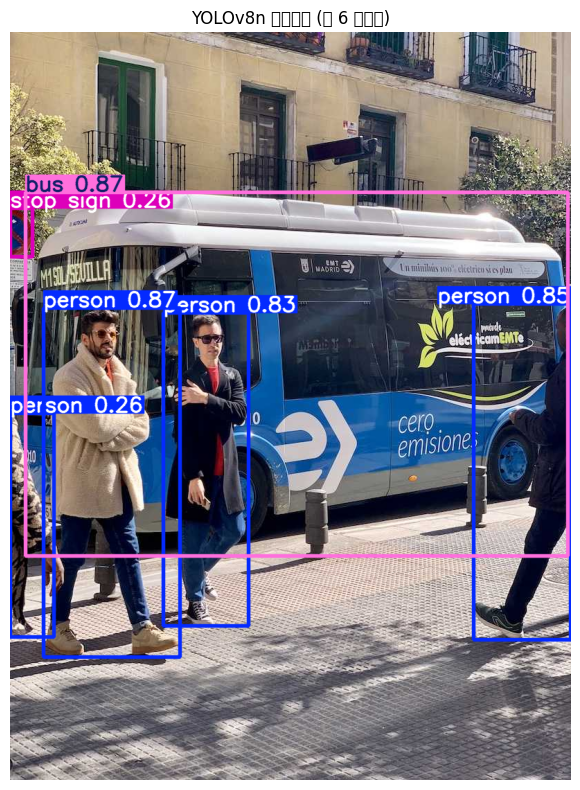

In [6]:
import matplotlib.pyplot as plt

# 从结果中获取带标注的图片（numpy 数组，BGR）
annotated = result.plot()  # BGR numpy array

# 转换 BGR -> RGB 并显示
plt.figure(figsize=(12, 8))
plt.imshow(annotated[..., ::-1])
plt.axis("off")
plt.title(f"YOLOv8n 检测结果 (共 {len(result.boxes)} 个目标)")
plt.tight_layout()
plt.savefig("./runs/test_builtin/result_display.png", dpi=150)
plt.show()
print("图片已保存到 ./runs/test_builtin/result_display.png")

## 5. 对本地图片推理

将你的图片放到 `./images/` 目录下，修改下方路径即可。

In [ ]:
import os

# ---- 修改此处为你的图片路径 ----
IMAGE_PATH = "./images/test.jpg"   # 支持 jpg/png/bmp 等格式
# ---------------------------------

if not os.path.exists(IMAGE_PATH):
    print(f"文件不存在: {IMAGE_PATH}")
    print("请将图片放到 ./images/ 目录，或修改 IMAGE_PATH 变量")
else:
    results = model.predict(
        source=IMAGE_PATH,
        save=True,
        project="./runs",
        name="test_local",
        exist_ok=True,
        conf=0.25,
        iou=0.45,   # NMS IoU 阈值
    )
    result = results[0]
    annotated = result.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated[..., ::-1])
    plt.axis("off")
    plt.title(f"本地图片检测结果 (共 {len(result.boxes)} 个目标)")
    plt.show()

## 6. 批量推理 & 性能统计

In [ ]:
import time
import glob

image_dir = "./images"
image_files = glob.glob(f"{image_dir}/*.jpg") + glob.glob(f"{image_dir}/*.png")

if not image_files:
    print(f"./images/ 目录下无图片，跳过批量推理")
else:
    print(f"找到 {len(image_files)} 张图片，开始批量推理...")
    t0 = time.time()
    results = model.predict(
        source=image_files,
        save=True,
        project="./runs",
        name="test_batch",
        exist_ok=True,
        conf=0.25,
        batch=4,         # 批量大小（CPU 建议 1~4）
        verbose=False,
    )
    elapsed = time.time() - t0
    print(f"推理完成: {len(results)} 张, 总耗时 {elapsed:.2f}s, 平均 {elapsed/len(results)*1000:.1f}ms/张")

    for r, path in zip(results, image_files):
        print(f"  {Path(path).name}: {len(r.boxes)} 个目标")

---

## 实验例1：彩色图像转灰度图

**目标：** 将彩色 RGB 图片转换为黑白（灰度）图片

### 灰度转换公式

$$L = R \times \frac{299}{1000} + G \times \frac{587}{1000} + B \times \frac{114}{1000}$$

三通道权重不同（绿色最高，蓝色最低），符合人眼对颜色的感知特性。PIL 的 `convert("L")` 会自动按此公式加权计算，无需手动处理每个像素。

| 模式 | 说明 |
|------|------|
| RGB  | 每像素 3 × 8 bit，彩色 |
| L    | 每像素 8 bit，灰度（0=黑，255=白）|

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib

# 设置中文字体（Windows 可用 SimHei / Microsoft YaHei）
matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False  # 负号正常显示

# 1. 打开彩色图片
im = Image.open("bus.jpg")
print(f"原始图片模式: {im.mode},  尺寸: {im.size}")

# 2. 转换为灰度（PIL 自动按 L = R×0.299 + G×0.587 + B×0.114 计算）
im_l = im.convert("L")
print(f"转换后模式:   {im_l.mode},  尺寸: {im_l.size}")

# 3. 对比显示
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(im)
axes[0].set_title(f"原始彩色图 (模式: {im.mode})")
axes[0].axis("off")

axes[1].imshow(im_l, cmap="gray")
axes[1].set_title(f"灰度图 (模式: {im_l.mode})")
axes[1].axis("off")

plt.suptitle("实验例1：彩色图像转灰度图", fontsize=14)
plt.tight_layout()
plt.savefig("output1_compare.jpg", dpi=150)
plt.show()

# 4. 保存灰度图
im_l.save("output1.jpg")
print("已保存: output1.jpg")
print("已保存: output1_compare.jpg（对比图）")

---

## 实验例2：彩色图像转"底片"模式

**目标：** 将彩色图片先转为灰度，再对每个像素取反，得到底片效果

### 底片原理

$$b = 255 - a$$

原来越亮的像素（$a$ 大）变暗，越暗的像素（$a$ 小）变亮，形成胶片底片效果。

### PIL + NumPy 结合使用

| 步骤 | 方法 | 说明 |
|------|------|------|
| 图像 → 数组 | `np.array(im)` | 转为可数学运算的矩阵 |
| 像素取反 | `255 - a` | 矩阵级操作，高效批量处理 |
| 数组 → 图像 | `Image.fromarray(b.astype('uint8'))` | `uint8` 不可省略，PIL 要求 0~255 整数类型 |

In [ ]:
from PIL import Image
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# 1. 打开图片并转为灰度，再转为 NumPy 数组
a = np.array(Image.open("bus.jpg").convert('L'))
print(f"数组形状: {a.shape}, 数据类型: {a.dtype}")
print(f"像素值范围: min={a.min()}, max={a.max()}")

# 2. 像素取反（底片效果）：b = 255 - a
b = 255 - a
print(f"取反后范围: min={b.min()}, max={b.max()}")

# 3. 数组转回 PIL 图像（必须指定 uint8）
im_neg = Image.fromarray(b.astype('uint8'))

# 4. 三图对比显示：原彩图 / 灰度图 / 底片
im_orig = Image.open("bus.jpg")
im_gray = Image.open("output1.jpg")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(im_orig)
axes[0].set_title("原始彩色图")
axes[0].axis("off")

axes[1].imshow(im_gray, cmap="gray")
axes[1].set_title("灰度图（例1结果）")
axes[1].axis("off")

axes[2].imshow(im_neg, cmap="gray")
axes[2].set_title("底片图（255 - 灰度）")
axes[2].axis("off")

plt.suptitle("实验例2：彩色图像转底片模式", fontsize=14)
plt.tight_layout()
plt.savefig("output2_compare.jpg", dpi=150)
plt.show()

# 5. 保存底片图
im_neg.save("output2.jpg")
print("已保存: output2.jpg")
print("已保存: output2_compare.jpg（三图对比）")

---

## 实验例3：OpenCV 图像读、写和显示操作

**目标：** 学会使用 OpenCV 完成图像的基本读取、显示和保存操作

### OpenCV 读取模式

| 参数 | 数值 | 含义 |
|------|------|------|
| `cv.IMREAD_COLOR` | `1` | 彩色模式（默认，通道顺序 **BGR**） |
| `cv.IMREAD_GRAYSCALE` | `0` | 灰度模式读取 |
| `cv.IMREAD_UNCHANGED` | `-1` | 原始模式（保留透明通道） |

> **注意：** OpenCV 彩色图通道顺序为 **BGR**，与 PIL 的 RGB 相反。在 matplotlib 中显示彩色图时需先转换：`img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)`
>
> `cv.imshow()` 需要 GUI 窗口，在 Jupyter Notebook 中用 **matplotlib** 替代显示。

彩色模式  shape: (1080, 810, 3), dtype: uint8
灰度模式  shape: (1080, 810, 1),  dtype: uint8
原始模式  shape: (1080, 810, 3),  dtype: uint8


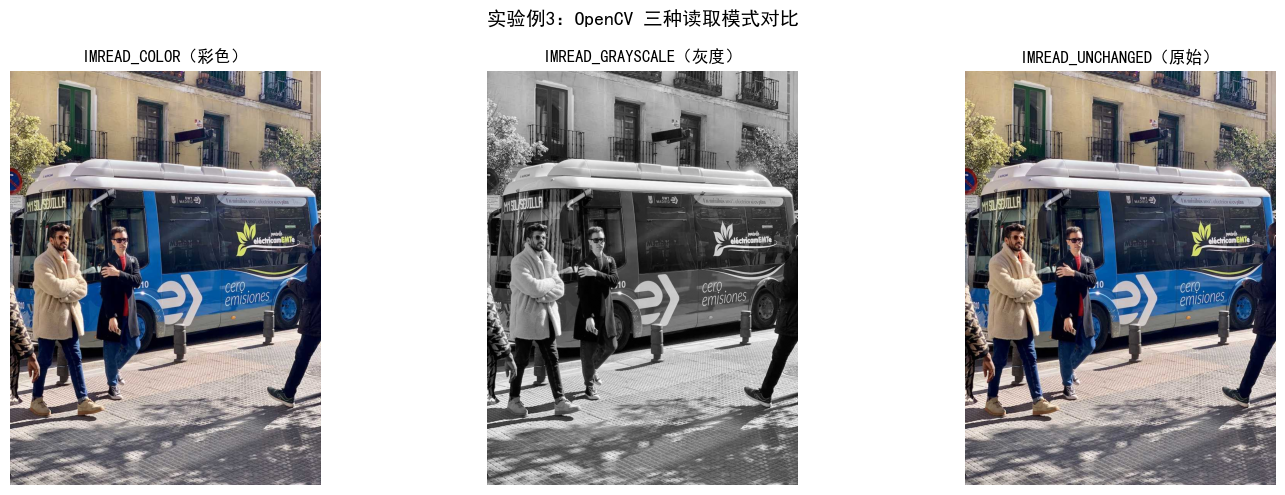

已保存: output3_gray.png
已保存: output3_color.jpg
已保存: output3_compare.jpg（三模式对比）


In [7]:
import numpy as np
import cv2 as cv
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['font.family'] = 'SimHei'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 1. 读取图像（三种模式）────────────────────────────────────────────
img_color = cv.imread('bus.jpg', cv.IMREAD_COLOR)      # 彩色（BGR）
img_gray  = cv.imread('bus.jpg', cv.IMREAD_GRAYSCALE)  # 灰度
img_unch  = cv.imread('bus.jpg', cv.IMREAD_UNCHANGED)  # 原始

print(f"彩色模式  shape: {img_color.shape}, dtype: {img_color.dtype}")
print(f"灰度模式  shape: {img_gray.shape},  dtype: {img_gray.dtype}")
print(f"原始模式  shape: {img_unch.shape},  dtype: {img_unch.dtype}")

# ── 2. 显示图像 ────────────────────────────────────────────────────────
# Jupyter 中用 matplotlib 代替 cv.imshow()
# 脚本环境下可使用：
#   cv.imshow('image', img_gray)
#   cv.waitKey(0)
#   cv.destroyAllWindows()

img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)  # BGR → RGB 供 matplotlib 正确显示

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("IMREAD_COLOR（彩色）")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
axes[1].set_title("IMREAD_GRAYSCALE（灰度）")
axes[1].axis("off")

axes[2].imshow(cv.cvtColor(img_unch, cv.COLOR_BGR2RGB))
axes[2].set_title("IMREAD_UNCHANGED（原始）")
axes[2].axis("off")

plt.suptitle("实验例3：OpenCV 三种读取模式对比", fontsize=14)
plt.tight_layout()
plt.savefig("output3_compare.jpg", dpi=150)
plt.show()

# ── 3. 保存图像 ────────────────────────────────────────────────────────
cv.imwrite('output3_gray.png', img_gray)   # 灰度图保存为 PNG
cv.imwrite('output3_color.jpg', img_color) # 彩色图保存为 JPG
print("已保存: output3_gray.png")
print("已保存: output3_color.jpg")
print("已保存: output3_compare.jpg（三模式对比）")